In [1]:
#import packages
import pandas as pd
import seaborn as sb
import pingouin as pg
import os
import scipy.stats as stats
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

#settings 
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')
plt.rcParams['figure.figsize'] = (6,4)
palette2={'E/N':'#FFC40C','N/N':'#00ABC8','E/E':'#F37243'}
palette1={'Baseline':"#AEAEAF",'Post':"#5F5C5C"}


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [70]:
def load_pairwise_df_all(bin_size): ### get the pairwise correlations for whole time. 
    '''
    bin_size: dataframes to load based on bin size in frame
    ''' 
    path=f'/Volumes/AM_SSD1/Spont2P/Analysis/correlation/pairwise_dataframes_rest_equalTime/0_lag/{bin_size}_bin_overlap'
    df_pre = pd.read_csv(os.path.join(path,'pairwise_corr_df_pre.csv'),index_col=0)
    df_post = pd.read_csv(os.path.join(path, 'pairwise_corr_df_post.csv'),index_col=0)

    return df_pre,df_post


def filter_by_pval(df_pre, df_post, p_thresh=0.05):
    """
    Filters rows where p-value is below threshold in both df_pre and df_post.
    """
    mask = (df_pre['pvals'] < p_thresh) & (df_post['pvals'] < p_thresh)
    
    df_pre_filtered = df_pre[mask].copy()
    df_post_filtered = df_post[mask].copy()
    
    return df_pre_filtered, df_post_filtered

def filter_single_df_by_pval(df, p_thresh=0.05):
    """
    Returns rows where p-value is below the given threshold.
    """
    return df[df['pvals'] < p_thresh].copy()


def mean_ani_thresholded(binsize,pvals=[.05,0.01, 0.001, 0.0001, 0.00001]):
    across_pvals = []
    df_long = []
    for pval in pvals:
        df_pre, df_post = load_pairwise_df_all(binsize)
        
        # Add ID to track cells
        df_pre['id'] = np.arange(len(df_pre))
        df_post['id'] = np.arange(len(df_post))

        # Apply cell-wise thresholding
        df1, df2 = filter_by_pval(df_pre, df_post, p_thresh=pval)
        
        # Remove bad values
        df1 = df1[~df1.eq(999).any(axis=1) & (df1['Spearmans R'] > 0)]
        df2 = df2[~df2.eq(999).any(axis=1) & (df2['Spearmans R'] > 0)]

        # Keep only ids that are present in both (optional safeguard)
        common_ids = set(df1['id']).intersection(df2['id'])
        df1 = df1[df1['id'].isin(common_ids)]
        df2 = df2[df2['id'].isin(common_ids)]

        # Merge on cell id to compute per-cell ratio
        df_merged = pd.merge(
            df1[['id', 'Spearmans R', 'Group', 'Animal', 'Pair Group']],
            df2[['id', 'Spearmans R']],
            on='id',
            suffixes=('_pre', '_post')
        )

        df_merged['R_ratio'] = df_merged['Spearmans R_post'] / df_merged['Spearmans R_pre']
        df_merged['R_diff'] = df_merged['Spearmans R_post'] - df_merged['Spearmans R_pre']
        df_merged['R_percent'] = (df_merged['Spearmans R_post'] - df_merged['Spearmans R_pre'])/(df_merged['Spearmans R_pre'])
        df_merged['thr'] = pval
        df_merged['bin_size'] = binsize * (1 / 30)

        df_long.append(df_merged)

        # Group per-animal AFTER ratio is computed
        df_grouped = df_merged.groupby(['Group', 'Animal', 'Pair Group'])['R_ratio'].mean().reset_index()
        df_grouped['thr'] = pval
        df_grouped['bin_size'] = binsize * (1 / 30)

        across_pvals.append(df_grouped)

    df_thr_long = pd.concat(df_long, ignore_index=True)
    plot_pvals = pd.concat(across_pvals, ignore_index=True)
    plot_pvals['Population']=plot_pvals['Pair Group'].map({'Tagged vs Tagged':'EE','Tagged vs Non-tagged':'EN','Non-tagged vs Non-tagged':'NN'})
    return plot_pvals,df_thr_long

In [103]:
plot_pvals,df_thr_wide = mean_ani_thresholded(32)

In [104]:
df_wide_1 = df_thr_wide.loc[df_thr_wide['thr'] ==0.05]
df_long = df_wide_1.melt(
    id_vars=['id', 'Group', 'Animal', 'Pair Group', 'R_ratio', 'R_diff','R_percent', 'thr', 'bin_size'],
    value_vars=['Spearmans R_pre', 'Spearmans R_post'],
    var_name='session',
    value_name='Spearmans R')

df_long['session'] = df_long['session'].map({
    'Spearmans R_pre': 'Baseline',
    'Spearmans R_post': 'Post'})

df_long.head()

,id,Group,Animal,Pair Group,R_ratio,R_diff,R_percent,thr,bin_size,session,Spearmans R
0,159,FC,989N,Tagged vs Tagged,0.578866,-0.072071,-0.421134,0.05,1.066667,Baseline,0.171136
1,228,FC,989N,Tagged vs Tagged,1.795281,0.068323,0.795281,0.05,1.066667,Baseline,0.085911
2,262,FC,989N,Tagged vs Tagged,2.394732,0.103246,1.394732,0.05,1.066667,Baseline,0.074025
3,297,FC,989N,Tagged vs Tagged,0.949911,-0.004458,-0.050089,0.05,1.066667,Baseline,0.089005
4,308,FC,989N,Tagged vs Tagged,0.350107,-0.137881,-0.649893,0.05,1.066667,Baseline,0.212159


In [105]:
label_map = {
    'Tagged vs Tagged':         'E/E',
    'Tagged vs Non-tagged':     'E/N',
    'Non-tagged vs Non-tagged': 'N/N',
}
df_long['Pair Group'] = df_long['Pair Group'].map(label_map)
pair_order = ['E/E','E/N','N/N']

In [106]:
df_long

,id,Group,Animal,Pair Group,R_ratio,R_diff,R_percent,thr,bin_size,session,Spearmans R
0,159,FC,989N,E/E,0.578866,-0.072071,-0.421134,0.05,1.066667,Baseline,0.171136
1,228,FC,989N,E/E,1.795281,0.068323,0.795281,0.05,1.066667,Baseline,0.085911
2,262,FC,989N,E/E,2.394732,0.103246,1.394732,0.05,1.066667,Baseline,0.074025
3,297,FC,989N,E/E,0.949911,-0.004458,-0.050089,0.05,1.066667,Baseline,0.089005
4,308,FC,989N,E/E,0.350107,-0.137881,-0.649893,0.05,1.066667,Baseline,0.212159
...,...,...,...,...,...,...,...,...,...,...,...
5421,100593,HC,1912L,E/N,2.721049,0.157886,1.721049,0.05,1.066667,Post,0.249624
5422,100595,HC,1912L,E/N,4.506353,0.230804,3.506353,0.05,1.066667,Post,0.296629
5423,100611,HC,1912L,E/N,1.464554,0.030923,0.464554,0.05,1.066667,Post,0.097489
5424,100616,HC,1912L,E/N,0.709713,-0.055885,-0.290287,0.05,1.066667,Post,0.136632


In [107]:
df_long['sign'] = np.sign(df_long['R_diff'])
df_long['R_diff_abs'] = np.abs(df_long['R_diff'])

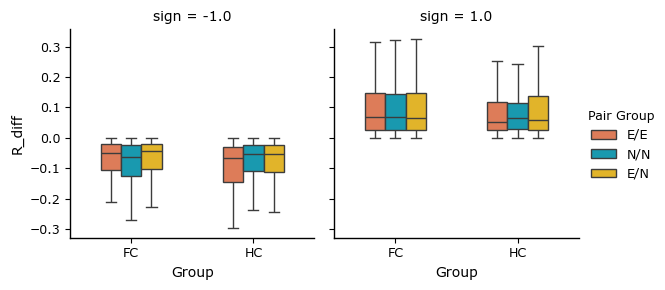

In [108]:
g = sb.catplot(col='sign',data = df_long,kind='box', x='Group',showfliers=False,palette=palette2,
                y='R_diff', hue='Pair Group', height=3,width=.5, aspect=1, gap=0,)

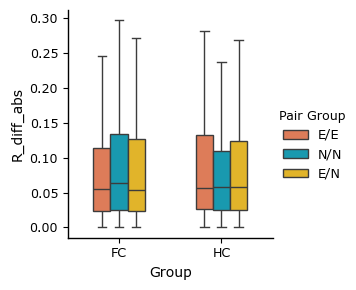

In [109]:
g = sb.catplot(data = df_long,kind='box', x='Group',showfliers=False,palette=palette2,
                y='R_diff_abs', hue='Pair Group', height=3,width=.5, aspect=1, gap=0,)

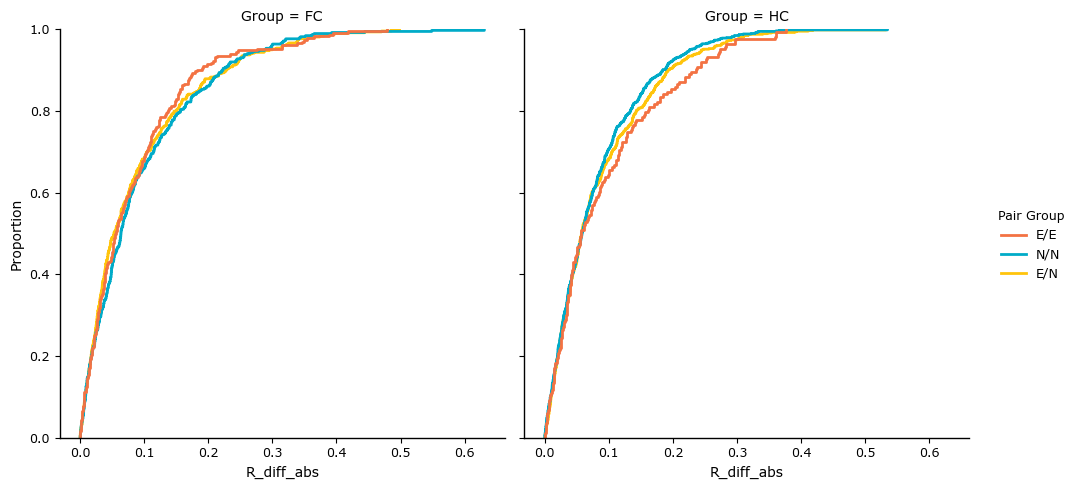

In [110]:
g = sb.displot(col='Group',data = df_long,kind='ecdf', x='R_diff_abs',palette=palette2,
                 hue='Pair Group')